# Unstructured Data Lab: QuickKart Customer Reviews (Free Text)

**Course:** Big Data Analytics — MBA BA, Trim IV
**Business Case:** QuickKart's customer support team is drowning in text — can we find the real problem at scale?

---

### Why unstructured data is the hardest of the three

- **Structured** (Notebook 1): every order is a row with fixed columns.
- **Semi-structured** (Notebook 2): every order is a JSON document — fields can vary, but there's still a recognizable key-value shape.
- **Unstructured** (this notebook): customer reviews are just... sentences. No columns, no keys, no guaranteed structure at all. A computer has *zero* built-in understanding of what's inside a block of text until we impose some structure on it ourselves.

Roughly 80–90% of the data most companies generate — reviews, support tickets, chat logs, call transcripts, images — is unstructured. QuickKart's customer support inbox is exactly this kind of data.

### The business question

> **"Customer complaints are up. Support agents are manually reading hundreds of reviews a day. Can we automatically surface what customers are actually complaining about, at scale, without reading every single review by hand?"**

This is a real, common first step into text analytics: before any fancy NLP or sentiment models, most companies start with **word frequency counting** — literally the same MapReduce word-count pattern used to teach distributed computing in every Hadoop course ever written. It turns out the "hello world" of MapReduce is also a legitimate first pass at a real business problem.


In [12]:
import random, os, shutil
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

random.seed(3)

# Building blocks for synthetic reviews: mix of praise, complaints, and neutral filler.
# Complaints are grouped by ROOT-CAUSE THEME (not just one flat bucket) so we can later ask
# not just "is this a complaint?" but "what KIND of problem is it?" — the theme is what a
# support/ops team actually needs to act on.
positive_snippets = [
    "delivery was super fast", "great quality produce", "app is really easy to use",
    "loved the packaging", "customer service was helpful", "fresh vegetables every time",
    "amazing discounts this week", "quick and reliable service",
]
negative_snippets_by_theme = {
    "Quality":    ["items arrived damaged", "produce was rotten", "wrong items delivered", "missing items in my order"],
    "Logistics":  ["delivery was very late", "order got cancelled without warning", "delivery was late again"],
    "Technical":  ["app kept crashing at checkout", "payment failed twice"],
    "Service":    ["customer service did not respond", "delivery driver was rude"],
}
neutral_snippets = [
    "ordered groceries for the week", "used the app on my phone", "paid using UPI",
    "placed the order in the evening", "used a promo code at checkout",
]

categories = ["Fruits & Vegetables", "Dairy", "Snacks", "Beverages", "Household"]

# Real businesses don't see complaints spread evenly across product lines — perishables fail
# differently than shelf-stable goods, and bulky multi-item orders fail differently than simple
# ones. We bake that unevenness in on purpose (same idea as the Polars lab's festive multipliers):
# without it, any "which category has the worst problem" analysis below would just be noise.
CATEGORY_COMPLAINT_RATE_MULTIPLIER = {  # overall likelihood a snippet drawn for this category is negative at all
    "Fruits & Vegetables": 1.3,   # perishable — spoils in transit
    "Dairy": 1.4,                 # perishable, cold-chain sensitive — the most fragile category here
    "Household": 1.1,             # bulky, multi-SKU orders — more room for mix-ups
    "Snacks": 0.7,                # shelf-stable, simple — least likely to go wrong
    "Beverages": 0.7,             # shelf-stable, simple — least likely to go wrong
}
CATEGORY_THEME_MULTIPLIER = {  # GIVEN a complaint, which root-cause theme is more/less likely for this category
    "Fruits & Vegetables": {"Quality": 3.0, "Logistics": 1.0, "Technical": 0.6, "Service": 0.8},
    "Dairy":               {"Quality": 3.2, "Logistics": 1.0, "Technical": 0.6, "Service": 0.8},
    "Household":           {"Quality": 1.8, "Logistics": 1.6, "Technical": 0.8, "Service": 1.0},
    "Snacks":               {"Quality": 0.5, "Logistics": 1.0, "Technical": 1.0, "Service": 1.0},
    "Beverages":            {"Quality": 0.5, "Logistics": 1.0, "Technical": 1.0, "Service": 1.0},
}
BASE_NEGATIVE_WEIGHT = 1.5  # baseline weight per negative snippet, before category multipliers scale it

def build_weighted_pool(category):
    "Build this category's own (snippet, weight) pool — same positive/neutral snippets for everyone, but negative snippet weights shift by category."
    pool, weights = [], []
    for s in positive_snippets:
        pool.append(s); weights.append(1)
    for s in neutral_snippets:
        pool.append(s); weights.append(1)
    for theme, snippets in negative_snippets_by_theme.items():
        theme_mult = CATEGORY_THEME_MULTIPLIER[category][theme]
        for s in snippets:
            pool.append(s)
            weights.append(BASE_NEGATIVE_WEIGHT * CATEGORY_COMPLAINT_RATE_MULTIPLIER[category] * theme_mult)
    return pool, weights

def generate_review():
    category = random.choice(categories)   # pick the category FIRST, since it drives the snippet weighting
    pool, weights = build_weighted_pool(category)
    n_snippets = random.randint(1, 3)
    chosen = random.choices(pool, weights=weights, k=n_snippets)
    return category, f"Order category: {category}. " + ". ".join(chosen) + "."

N_REVIEWS = 2000   # enough volume that per-category, per-theme percentages are stable, not noisy
reviews_with_category = [generate_review() for _ in range(N_REVIEWS)]
reviews = [text for _, text in reviews_with_category]   # keep the flat text list for the MapReduce section below

print(f"Generated {N_REVIEWS} customer reviews. Example:\n")
for r in reviews[:3]:
    print("-", r)


Generated 2000 customer reviews. Example:

- Order category: Dairy. wrong items delivered. items arrived damaged. wrong items delivered.
- Order category: Household. missing items in my order.
- Order category: Beverages. used a promo code at checkout. customer service was helpful.


This is what unstructured data looks like: free-form sentences with no guaranteed vocabulary, no fixed length, and business-relevant signal (which category, whether it's a complaint) buried inside plain English rather than sitting in a clean column.


In [13]:
# Store reviews as raw .txt files split across 3 "node" folders — same storage
# concept as the HDFS notebook, just applied to text instead of CSV rows.
if os.path.exists("text_cluster"):
    shutil.rmtree("text_cluster")

for node in ["node1", "node2", "node3"]:
    os.makedirs(f"text_cluster/{node}", exist_ok=True)

chunk_size = len(reviews) // 3
chunks = [reviews[0:chunk_size], reviews[chunk_size:2*chunk_size], reviews[2*chunk_size:]]

for i, (node, chunk) in enumerate(zip(["node1", "node2", "node3"], chunks), start=1):
    path = f"text_cluster/{node}/reviews_block{i}.txt"
    with open(path, "w") as f:
        f.write("\n".join(chunk))
    print(f"{path}: {len(chunk)} reviews")


text_cluster/node1/reviews_block1.txt: 666 reviews
text_cluster/node2/reviews_block2.txt: 666 reviews
text_cluster/node3/reviews_block3.txt: 668 reviews


## MapReduce Word Count — the classic starting point for text at scale

### Map phase
Each node reads its own block of reviews and counts word frequency *independently* — no coordination with other nodes needed yet.

### Shuffle + Reduce phase
Word counts from all 3 nodes get combined into one global frequency table.


In [3]:
import re
from collections import Counter
import multiprocessing as mp

STOPWORDS = {
    "the", "a", "an", "was", "is", "at", "in", "for", "my", "this", "and", "to",
    "of", "on", "with", "again", "order", "category", "used", "ordered",
}

def clean_and_tokenize(text):
    # Strip the structural "Order category: X." prefix BEFORE tokenizing — it's metadata we
    # added ourselves, not something a customer wrote, so it shouldn't count as review content.
    # (Without this, every category name shows up as a top "complaint" word purely because it's
    # in every single review's opening sentence — that's noise, not signal.)
    text = re.sub(r"order category:\s*[^.]+\.", " ", text, flags=re.IGNORECASE)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # strip ALL punctuation (periods, commas, colons, ...), not just . and ,
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def map_word_count(filepath):
    """MAP: tokenize this node's block and count word frequency, independently."""
    with open(filepath) as f:
        text = f.read()
    words = clean_and_tokenize(text)
    return Counter(words)

block_paths = [
    "text_cluster/node1/reviews_block1.txt",
    "text_cluster/node2/reviews_block2.txt",
    "text_cluster/node3/reviews_block3.txt",
]

ctx = mp.get_context("fork")
with ctx.Pool(3) as pool:
    partial_counts = pool.map(map_word_count, block_paths)

for i, counter in enumerate(partial_counts, start=1):
    print(f"Top 5 words from node{i} (independent, before combining):")
    print(counter.most_common(5))
    print()


Top 5 words from node1 (independent, before combining):
[('items', 288), ('delivery', 205), ('app', 144), ('produce', 140), ('service', 131)]

Top 5 words from node2 (independent, before combining):
[('items', 283), ('delivery', 237), ('late', 153), ('app', 132), ('produce', 127)]

Top 5 words from node3 (independent, before combining):
[('items', 304), ('delivery', 228), ('service', 143), ('produce', 136), ('late', 132)]



In [4]:
# SHUFFLE + REDUCE: merge all 3 nodes' partial word counts into one global count
global_counts = Counter()
for partial in partial_counts:
    global_counts.update(partial)

top_words = pd.DataFrame(global_counts.most_common(15), columns=["word", "count"])
top_words


,word,count
0,items,875
1,delivery,670
2,app,408
3,late,403
4,produce,403
5,service,394
6,arrived,318
7,damaged,318
8,rotten,298
9,wrong,292


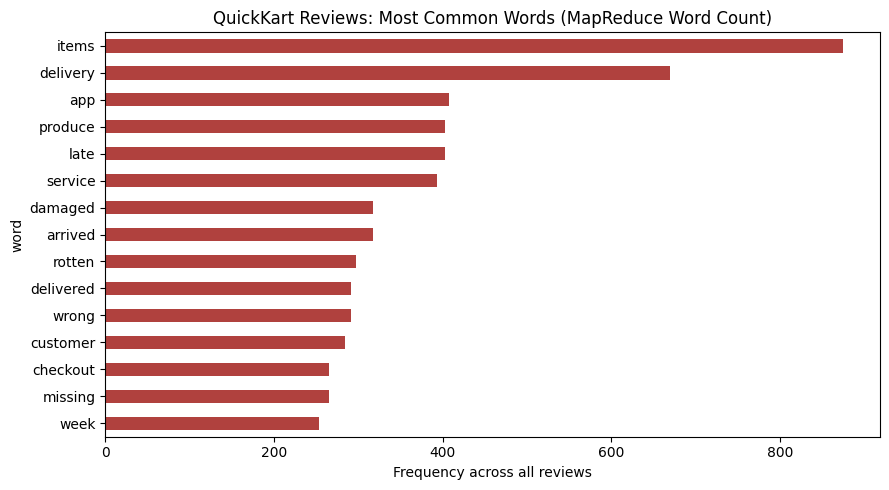

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
top_words.set_index("word")["count"].sort_values().plot(kind="barh", ax=ax, color="#B0413E")
ax.set_xlabel("Frequency across all reviews")
ax.set_title("QuickKart Reviews: Most Common Words (MapReduce Word Count)")
plt.tight_layout()
plt.show()


Notice words like *"delivery"*, *"late"*, *"damaged"*, and *"crashing"* should be surfacing near the top — the word-count alone, with zero fancy NLP, is already pointing straight at where the operational problems are.


## Turning Word Counts into a Business Answer: Simple Complaint Detection

Raw word frequency is useful, but a business stakeholder wants a sharper answer: **what fraction of reviews are actual complaints, and about what?** We'll use a lightweight keyword-matching approach — the same "good enough to be useful" logic companies often reach for before investing in a full sentiment-analysis model.


In [6]:
COMPLAINT_THEMES = {  # same theme groupings used when we generated the data — now used to CLASSIFY it back
    "Quality":   {"damaged", "rotten", "wrong", "missing"},
    "Logistics": {"late", "cancelled"},
    "Technical": {"crashing", "failed"},
    "Service":   {"rude", "respond"},
}
ALL_COMPLAINT_KEYWORDS = set().union(*COMPLAINT_THEMES.values())

def classify_review(text):
    "Return (classification, list_of_themes_hit) — a review can hit more than one theme if it has multiple negative snippets."
    words = set(clean_and_tokenize(text))
    hit_themes = [theme for theme, kws in COMPLAINT_THEMES.items() if words & kws]
    if not hit_themes:
        return "Non-complaint", []
    return "Complaint", hit_themes

review_df = pd.DataFrame({"review": reviews, "category": [c for c, _ in reviews_with_category]})
classified = review_df["review"].apply(classify_review)
review_df["classification"] = classified.apply(lambda t: t[0])
review_df["themes"] = classified.apply(lambda t: t[1])

review_df.head(8)


,review,category,classification,themes
0,Order category: Dairy. wrong items delivered. ...,Dairy,Complaint,[Quality]
1,Order category: Household. missing items in my...,Household,Complaint,[Quality]
2,Order category: Beverages. used a promo code a...,Beverages,Non-complaint,[]
3,Order category: Beverages. app kept crashing a...,Beverages,Complaint,"[Quality, Technical]"
4,Order category: Dairy. wrong items delivered.,Dairy,Complaint,[Quality]
5,Order category: Household. order got cancelled...,Household,Complaint,[Logistics]
6,Order category: Fruits & Vegetables. missing i...,Fruits & Vegetables,Complaint,[Quality]
7,Order category: Household. placed the order in...,Household,Non-complaint,[]


In [7]:
# Business-facing summary: complaint rate AND volume, by category.
# Rate alone can mislead — a tiny category with a high rate looks alarming but may not matter much;
# pairing rate with volume tells a manager where the *total impact* actually is.
overall_rate = (review_df["classification"] == "Complaint").mean() * 100
print(f"Overall complaint rate: {overall_rate:.1f}% of reviews\n")

by_category = (
    review_df.groupby("category")
    .agg(
        TotalReviews=("classification", "size"),
        Complaints=("classification", lambda s: (s == "Complaint").sum()),
    )
)
by_category["ComplaintRatePct"] = (by_category["Complaints"] / by_category["TotalReviews"] * 100).round(1)
by_category = by_category.sort_values("ComplaintRatePct", ascending=False)
print("Complaint rate AND volume by category:")
by_category


Overall complaint rate: 75.8% of reviews

Complaint rate AND volume by category:


,TotalReviews,Complaints,ComplaintRatePct
category,,,
Dairy,381,339,89.0
Fruits & Vegetables,408,363,89.0
Household,388,314,80.9
Snacks,425,260,61.2
Beverages,398,240,60.3


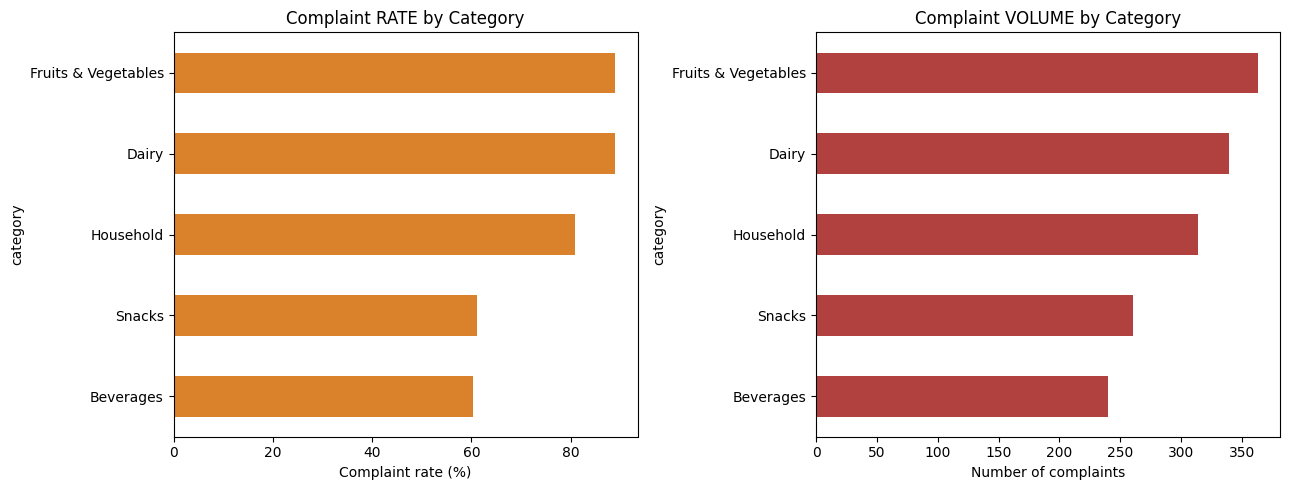

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

by_category["ComplaintRatePct"].sort_values().plot(kind="barh", ax=axes[0], color="#D9822B")
axes[0].set_xlabel("Complaint rate (%)")
axes[0].set_title("Complaint RATE by Category")

by_category["Complaints"].sort_values().plot(kind="barh", ax=axes[1], color="#B0413E")
axes[1].set_xlabel("Number of complaints")
axes[1].set_title("Complaint VOLUME by Category")

plt.tight_layout()
plt.show()


### Root-cause breakdown: not just "is it a complaint," but "what KIND of complaint?"

A complaint rate alone tells support leadership *that* something's wrong, not *what* to fix. We
already tagged every negative snippet with a root-cause theme (Quality, Logistics, Technical,
Service) when we generated the data — now we recover that structure from the free text, the same
way a real support team would tag incoming tickets.


Complaint root causes, overall (theme mentions across all complaints):
Quality      893
Logistics    535
Service      291
Technical    258
dtype: int64


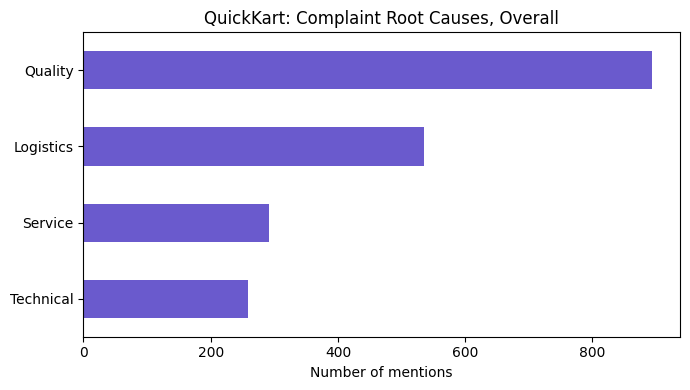

In [9]:
# A review can hit more than one theme (e.g. both "late" AND "damaged") — so we count theme HITS,
# not reviews, when asking "which root cause is most common overall."
theme_hits = Counter(theme for themes in review_df["themes"] for theme in themes)
theme_overall = pd.Series(theme_hits).sort_values(ascending=False)
print("Complaint root causes, overall (theme mentions across all complaints):")
print(theme_overall)

fig, ax = plt.subplots(figsize=(7, 4))
theme_overall.sort_values().plot(kind="barh", ax=ax, color="#6A5ACD")
ax.set_xlabel("Number of mentions")
ax.set_title("QuickKart: Complaint Root Causes, Overall")
plt.tight_layout()
plt.show()


### Which root cause dominates each category? (the actionable part)

This is the chart a support/ops leader actually needs: not "Dairy has more complaints" but
"Dairy's complaints are specifically about *Quality* — that points at cold-chain, not the app or
the delivery drivers." Different categories should get different fixes.


Root-cause mix within each category's complaints (%):
themes               Quality  Logistics  Technical  Service
category                                                   
Beverages               24.3       30.3       22.0     23.3
Dairy                   60.9       19.6        8.4     11.1
Fruits & Vegetables     58.0       24.2        8.0      9.9
Household               46.4       29.4       10.7     13.5
Snacks                  22.0       35.7       21.7     20.5


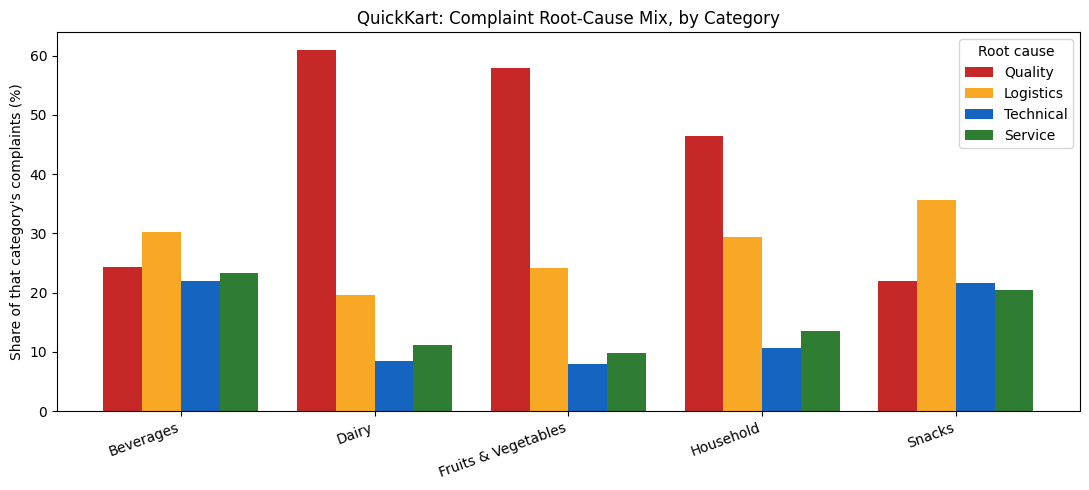

In [10]:
# Explode: one row per (category, theme) hit, so each theme mention is counted once per category.
exploded = review_df.explode("themes").dropna(subset=["themes"])
theme_by_category = (
    exploded.groupby(["category", "themes"]).size()
    .unstack("themes", fill_value=0)
)
theme_by_category = theme_by_category[["Quality", "Logistics", "Technical", "Service"]]  # fixed column order
# Normalize to a % of that category's own complaint mentions, so categories are comparable
# regardless of how many total complaints they have.
theme_by_category_pct = (theme_by_category.div(theme_by_category.sum(axis=1), axis=0) * 100).round(1)
print("Root-cause mix within each category's complaints (%):")
print(theme_by_category_pct)

import numpy as np
cats = theme_by_category_pct.index.tolist()
themes = theme_by_category_pct.columns.tolist()
x = np.arange(len(cats))
width = 0.2
colors = {"Quality": "#C62828", "Logistics": "#F9A825", "Technical": "#1565C0", "Service": "#2E7D32"}

fig, ax = plt.subplots(figsize=(11, 5))
for i, theme in enumerate(themes):
    offset = (i - 1.5) * width
    ax.bar(x + offset, theme_by_category_pct[theme], width, label=theme, color=colors[theme])
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=20, ha="right")
ax.set_ylabel("Share of that category's complaints (%)")
ax.set_title("QuickKart: Complaint Root-Cause Mix, by Category")
ax.legend(title="Root cause")
plt.tight_layout()
plt.show()


### Turning this into a support/ops action plan

Same move as the Polars lab's business case: don't stop at the chart, turn it into a per-category
recommendation a support leader could act on this week.


In [11]:
theme_action = {  # what an ops/support team would actually do about each root-cause theme
    "Quality":   "audit cold-chain handling, packaging, and warehouse quality checks",
    "Logistics": "review delivery routing/scheduling and cancellation handling",
    "Technical": "prioritize app/checkout and payment-gateway stability fixes",
    "Service":   "retrain support staff and delivery-agent customer interactions",
}

print("SUPPORT & OPS ACTION PLAN\n" + "=" * 60)
for category in by_category.index:   # already sorted by complaint rate, highest first
    rate = by_category.loc[category, "ComplaintRatePct"]
    volume = int(by_category.loc[category, "Complaints"])
    dominant_theme = theme_by_category_pct.loc[category].idxmax()          # derived from the data, not assumed
    dominant_share = theme_by_category_pct.loc[category, dominant_theme]
    print(f"{category}: {rate}% complaint rate, {volume} complaints — dominant issue: "
          f"{dominant_theme} ({dominant_share}% of its complaints)\n  -> {theme_action[dominant_theme]}")

lowest_priority = by_category["ComplaintRatePct"].idxmin()
print(f"\nLowest priority this cycle: {lowest_priority} "
      f"(lowest complaint rate: {by_category.loc[lowest_priority, 'ComplaintRatePct']}%)")


SUPPORT & OPS ACTION PLAN
Dairy: 89.0% complaint rate, 339 complaints — dominant issue: Quality (60.9% of its complaints)
  -> audit cold-chain handling, packaging, and warehouse quality checks
Fruits & Vegetables: 89.0% complaint rate, 363 complaints — dominant issue: Quality (58.0% of its complaints)
  -> audit cold-chain handling, packaging, and warehouse quality checks
Household: 80.9% complaint rate, 314 complaints — dominant issue: Quality (46.4% of its complaints)
  -> audit cold-chain handling, packaging, and warehouse quality checks
Snacks: 61.2% complaint rate, 260 complaints — dominant issue: Logistics (35.7% of its complaints)
  -> review delivery routing/scheduling and cancellation handling
Beverages: 60.3% complaint rate, 240 complaints — dominant issue: Logistics (30.3% of its complaints)
  -> review delivery routing/scheduling and cancellation handling

Lowest priority this cycle: Beverages (lowest complaint rate: 60.3%)


### Business insight

Support leadership no longer has to read all 2,000 reviews to know where to focus. The data shows a
real, differentiated pattern (not just noise across similarly-behaved categories): **Dairy and Fruits
& Vegetables are Quality-dominant** (spoilage/damage in transit — a cold-chain and packaging problem),
**Household leans Quality too but with a real Logistics mix** (bulky, multi-item orders are more prone
to mis-picks), and **Snacks/Beverages have the lowest complaint rate overall, mostly Logistics** (they
survive transit fine — when something goes wrong it's more likely a delivery timing issue than a
product problem). That's four different root causes pointing at four different fixes, recovered
entirely from free text, without a single review being read manually.

## Recap: Structured vs. Semi-Structured vs. Unstructured

| | Structured (Notebook 1) | Semi-Structured (Notebook 2) | Unstructured (this notebook) |
|---|---|---|---|
| Example | Orders CSV | Nested JSON order documents | Free-text customer reviews |
| Schema | Fixed, known upfront | Flexible, key-value shaped | None — plain text |
| Effort before analysis | None — already tabular | Flatten nested structure | Tokenize, clean, classify |
| Typical first analytics step | groupby / aggregation | json_normalize + groupby | Word count → keyword rules → (eventually) NLP models |
| Real tools at scale | Hive, SQL-on-Hadoop | Spark JSON reader, MongoDB, Hive w/ SerDe | Spark NLP, Elasticsearch, LLM-based classification |

### Discussion questions for class

1. Our complaint classifier is just keyword matching — what kinds of complaints would it completely miss? (Sarcasm, polite-but-negative phrasing, complaints that don't use our exact keyword list.)
2. If QuickKart had 50 million reviews instead of 2,000, which part of this notebook would need real distributed infrastructure (a real Hadoop/Spark cluster) instead of a laptop's multiprocessing?
3. Compare the *effort required before you can ask a business question* across all three notebooks. What does that tell you about why unstructured data projects tend to take longer and cost more than structured-data projects?
4. Where might this simple keyword approach give a **false sense of confidence** to a business stakeholder who doesn't know its limitations?
5. **Rate vs. volume:** a category could have the highest complaint *rate* but a small *volume* (few total orders). Which should drive the support team's priority list — and when might they disagree?
6. **Root-cause vs. symptom:** we recovered "Quality" as Dairy's dominant theme from keyword co-occurrence, not from actually inspecting a spoiled product. What would you want to verify before spending a cold-chain audit budget based on this alone?
